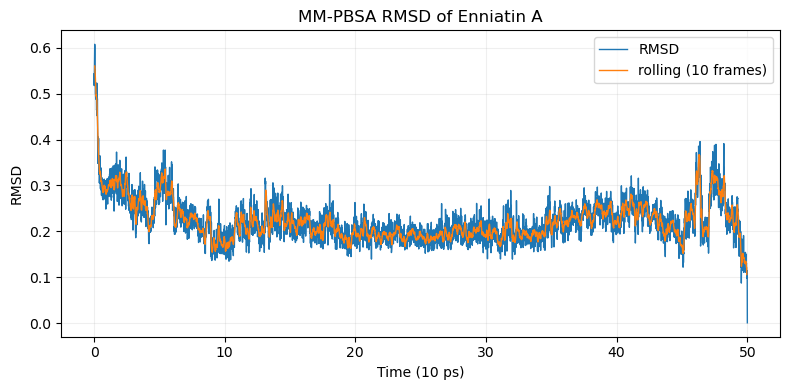

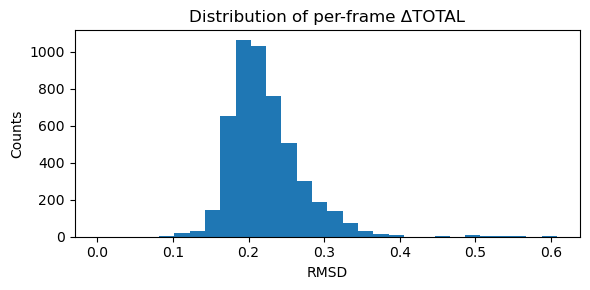

In [2]:
# save as plot_mmpbsa.py and run with python3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def read_xvg(fname):
    """Minimal reader for GROMACS .xvg and many .dat files: skip lines starting with @ or #."""
    data = []
    with open(fname) as f:
        for line in f:
            if line.strip() == "" or line.startswith(('@', '#')):
                continue
            parts = line.split()
            # accept lines with at least 2 numeric columns
            try:
                nums = [float(parts[0]), float(parts[1])]
                data.append(nums)
            except:
                continue
    return pd.DataFrame(data, columns=['time', 'delta_total'])

# Example: change filename to your per-frame file
df = read_xvg('MD/ENA/RMSD_ligand.xvg')   # or 'DELTA_TOTAL.dat', or 'FINAL_RESULTS_MMPBSA.dat' depending on your run

# If the file only has per-frame delta (no explicit time), treat 'time' as frame index
if df['time'].duplicated().all():  # fallback: no times
    df['time'] = np.arange(len(df))

# rolling average for smoothing
df['rolling'] = df['delta_total'].rolling(window=10, center=True).mean()

plt.figure(figsize=(8,4))
plt.plot(df['time'], df['delta_total'], label='RMSD', alpha=1, linewidth=1)
plt.plot(df['time'], df['rolling'], label='rolling (10 frames)', linewidth=1)
plt.xlabel('Time (10 ps)')
plt.ylabel('RMSD')
plt.title('MM-PBSA RMSD of Enniatin A')
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

# Also show histogram
plt.figure(figsize=(6,3))
plt.hist(df['delta_total'].dropna(), bins=30)
plt.xlabel('RMSD')
plt.ylabel('Counts')
plt.title('Distribution of per-frame ΔTOTAL')
plt.tight_layout()
plt.show()
